# Semana 14: Arco Narrativo - Contar historias con datos

En esta semana se busca transformar el análisis técnico realizado en semanas anteriores en una historia clara para la toma de decisiones.

Para ello, se recuperan los datos procesados y se organizan indicadores clave según tres niveles organizacionales:

- Nivel estratégico: pensado para la alta dirección, con una visión general del negocio.
- Nivel táctico: pensado para gerentes o encargados de área, con indicadores de seguimiento periódico.
- Nivel operacional: pensado para supervisores, con indicadores de control diario o en tiempo real.

El objetivo es conectar los datos con una pregunta de negocio y mostrar cómo estos indicadores pueden apoyar mejores decisiones dentro de la organización.

In [2]:
import os

base = "/home/jovyan/work"

for root, dirs, files in os.walk(base):
    if "Semana" in root or "semana" in root or "semanas" in root:
        print(root)

/home/jovyan/work/semanas
/home/jovyan/work/semanas/.ipynb_checkpoints
/home/jovyan/work/semanas/Reset
/home/jovyan/work/semanas/Reset/.ipynb_checkpoints
/home/jovyan/work/semanas/Semana 1 Configuración del Entorno
/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado
/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/salidas
/home/jovyan/work/semanas/Semana 12 Aprendizaje Semi Supervisado
/home/jovyan/work/semanas/Semana 12 Aprendizaje Semi Supervisado/salidas
/home/jovyan/work/semanas/Semana 14
/home/jovyan/work/semanas/Semana 14/.ipynb_checkpoints
/home/jovyan/work/semanas/Semana 2 Scrapping Estatico
/home/jovyan/work/semanas/Semana 2 Scrapping Estatico/.ipynb_checkpoints
/home/jovyan/work/semanas/Semana 3 Scraping Dinamico
/home/jovyan/work/semanas/Semana 3 Scraping Dinamico/.ipynb_checkpoints
/home/jovyan/work/semanas/Semana 4 Mongo DB
/home/jovyan/work/semanas/Semana 4 Mongo DB/.ipynb_checkpoints
/home/jovyan/work/semanas/Semana 5 MongoDB PySpark
/home/jovyan

In [5]:
from pyspark.sql import SparkSession

# Iniciar sesión Spark
spark = SparkSession.builder.appName("Storytelling_Final_Thalia").getOrCreate()

# Ruta real de tu archivo CSV de Semana 10
ruta_datos = "/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/salidas/clusters_energia_thalia.csv"

try:
    # Leer CSV con encabezados
    df_completos = spark.read.csv(ruta_datos, header=True, inferSchema=True)
    
    # Contar registros recuperados
    total_registros = df_completos.count()
    print(f"Conexión establecida. Se recuperaron {total_registros} registros.")
    
    # Mostrar primeras filas
    df_completos.show(5)
    
    # Mostrar columnas y tipos de datos
    df_completos.printSchema()

except Exception as e:
    print("No se pudo recuperar el archivo CSV.")
    print("Revisa si la ruta o el nombre del archivo están correctos.")
    print(e)

Conexión establecida. Se recuperaron 500 registros.
+--------------------+-----------+----------+-----------------+------------+----------+--------------+
|                item|       pais|tecnologia|categoria_energia|capacidad_mw|prediction|cluster_dbscan|
+--------------------+-----------+----------+-----------------+------------+----------+--------------+
|Kajaki Hydroelect...|Afghanistan|     Hydro|        Renovable|        33.0|         0|             0|
|Kandahar DOG - Solar|Afghanistan|     Solar|        Renovable|        10.0|         0|             0|
|Kandahar JOL - Solar|Afghanistan|     Solar|        Renovable|        10.0|         0|             0|
|Mahipar Hydroelec...|Afghanistan|     Hydro|        Renovable|        66.0|         0|             0|
|Naghlu Dam Hydroe...|Afghanistan|     Hydro|        Renovable|       100.0|         0|             0|
+--------------------+-----------+----------+-----------------+------------+----------+--------------+
only showing top 5 ro

## Pregunta de negocio

A partir de los datos de proyectos energéticos analizados, esta semana se busca responder:

**¿Cómo se distribuye la capacidad energética instalada según país, tecnología y categoría de energía, y qué indicadores permiten apoyar la toma de decisiones estratégicas, tácticas y operacionales en el sector energético?**

Para responder esta pregunta, se construirá una matriz de indicadores considerando tres niveles organizacionales:

- **Nivel estratégico:** visión global para la alta dirección.
- **Nivel táctico:** análisis intermedio para la gestión y planificación.
- **Nivel operacional:** seguimiento específico para la supervisión y control diario.

In [6]:
df_completos.columns

['item',
 'pais',
 'tecnologia',
 'categoria_energia',
 'capacidad_mw',
 'prediction',
 'cluster_dbscan']

In [7]:
df_completos.describe().show()

+-------+--------------------+-----------+----------+-----------------+------------------+------------------+----------------+
|summary|                item|       pais|tecnologia|categoria_energia|      capacidad_mw|        prediction|  cluster_dbscan|
+-------+--------------------+-----------+----------+-----------------+------------------+------------------+----------------+
|  count|                 500|        500|       500|              500|               500|               500|             500|
|   mean|                NULL|       NULL|      NULL|             NULL|151.67859400000003|             1.016|            0.49|
| stddev|                NULL|       NULL|      NULL|             NULL| 295.2236412228108|0.9662355936545138|0.53147429839995|
|    min|AGUA DEL CAJON (A...|Afghanistan|   Biomass|            Fosil|               1.0|                 0|              -1|
|    max|Zaouiet Kounta - ...|  Australia|      Wind|        Renovable|            2640.0|                 2|  

## Matriz de indicadores por nivel organizacional

| Nivel organizacional | KPI | Variable utilizada | Frecuencia de visualización | Objetivo de negocio |
|---|---|---|---|---|
| Estratégico | Participación de capacidad instalada por categoría energética | categoria_energia, capacidad_mw | Mensual / Trimestral | Identificar si la matriz energética se concentra en energías renovables o no renovables. |
| Táctico | Capacidad promedio por tecnología | tecnologia, capacidad_mw | Semanal / Mensual | Comparar tecnologías energéticas y apoyar decisiones de inversión o priorización. |
| Operacional | Proyectos de baja capacidad instalada | item, pais, tecnologia, capacidad_mw | Diario / Semanal | Detectar proyectos pequeños que requieren seguimiento o revisión técnica. |

In [8]:
import pyspark.sql.functions as F

# KPI Estratégico: participación de capacidad instalada por categoría energética
total_capacidad = df_completos.agg(F.sum("capacidad_mw")).collect()[0][0]

kpi_estrategico = df_completos.groupBy("categoria_energia") \
    .agg(
        F.round(F.sum("capacidad_mw"), 2).alias("Capacidad_Total_MW"),
        F.round((F.sum("capacidad_mw") / total_capacidad) * 100, 2).alias("Participacion_Porcentaje"),
        F.count("item").alias("Cantidad_Proyectos")
    ) \
    .orderBy(F.desc("Capacidad_Total_MW"))

print("KPI ESTRATÉGICO: Participación de capacidad instalada por categoría energética")
kpi_estrategico.show()

KPI ESTRATÉGICO: Participación de capacidad instalada por categoría energética
+-----------------+------------------+------------------------+------------------+
|categoria_energia|Capacidad_Total_MW|Participacion_Porcentaje|Cantidad_Proyectos|
+-----------------+------------------+------------------------+------------------+
|            Fosil|          55028.13|                   72.56|               295|
|        Renovable|          20811.17|                   27.44|               205|
+-----------------+------------------+------------------------+------------------+



In [9]:
# KPI Táctico: capacidad promedio por tecnología
kpi_tactico = df_completos.groupBy("tecnologia") \
    .agg(
        F.count("item").alias("Cantidad_Proyectos"),
        F.round(F.avg("capacidad_mw"), 2).alias("Capacidad_Promedio_MW"),
        F.round(F.min("capacidad_mw"), 2).alias("Capacidad_Minima_MW"),
        F.round(F.max("capacidad_mw"), 2).alias("Capacidad_Maxima_MW")
    ) \
    .orderBy(F.desc("Capacidad_Promedio_MW"))

print("KPI TÁCTICO: Capacidad promedio por tecnología")
kpi_tactico.show()

KPI TÁCTICO: Capacidad promedio por tecnología
+----------+------------------+---------------------+-------------------+-------------------+
|tecnologia|Cantidad_Proyectos|Capacidad_Promedio_MW|Capacidad_Minima_MW|Capacidad_Maxima_MW|
+----------+------------------+---------------------+-------------------+-------------------+
|      Coal|                20|               682.67|               13.2|             2640.0|
|   Nuclear|                 4|                534.5|              370.0|              745.0|
|     Other|                 3|               474.15|               98.0|             845.26|
|       Gas|               136|               265.84|               1.04|             1217.7|
|     Hydro|                96|               159.97|                2.5|             1550.0|
|      Wind|                42|                51.98|                1.0|              240.0|
|     Solar|                65|                49.28|                1.0|              500.0|
|   Biomass| 

In [10]:
# KPI Operacional: proyectos con baja capacidad instalada
kpi_operacional = df_completos.filter(F.col("capacidad_mw") < 20) \
    .select("item", "pais", "tecnologia", "categoria_energia", "capacidad_mw") \
    .orderBy(F.asc("capacidad_mw"))

print("KPI OPERACIONAL: Proyectos con baja capacidad instalada")
print(f"Total de proyectos bajo 20 MW: {kpi_operacional.count()}")
kpi_operacional.show(20, truncate=False)

KPI OPERACIONAL: Proyectos con baja capacidad instalada
Total de proyectos bajo 20 MW: 193
+---------------------------------------------+----------+----------+-----------------+------------+
|item                                         |pais      |tecnologia|categoria_energia|capacidad_mw|
+---------------------------------------------+----------+----------+-----------------+------------+
|Ross Island - Wind                           |Antarctica|Wind      |Renovable        |1.0         |
|Adelaide Showgrounds - Solar                 |Australia |Solar     |Renovable        |1.0         |
|Belconnen - Waste                            |Australia |Waste     |Fosil            |1.0         |
|Blue Lake Milling Power Plant - Oil          |Australia |Oil       |Fosil            |1.0         |
|Corio - Waste                                |Australia |Waste     |Fosil            |1.0         |
|Elliott - Oil                                |Australia |Oil       |Fosil            |1.0         |


## Interpretación inicial

Los indicadores permiten transformar los datos técnicos en información útil para la toma de decisiones.

A nivel **estratégico**, la participación de capacidad instalada por categoría energética permite observar si la matriz analizada depende principalmente de energías renovables o no renovables.

A nivel **táctico**, la capacidad promedio por tecnología permite comparar el comportamiento de distintas fuentes energéticas, identificando cuáles concentran proyectos de mayor escala.

A nivel **operacional**, el listado de proyectos con baja capacidad instalada permite detectar casos que podrían requerir seguimiento, revisión técnica o evaluación de eficiencia.

De esta forma, el análisis deja de ser solo descriptivo y se convierte en una herramienta para apoyar decisiones en distintos niveles de la organización.

In [11]:
kpi_estrategico.show()
kpi_tactico.show()
kpi_operacional.show(20, truncate=False)

+-----------------+------------------+------------------------+------------------+
|categoria_energia|Capacidad_Total_MW|Participacion_Porcentaje|Cantidad_Proyectos|
+-----------------+------------------+------------------------+------------------+
|            Fosil|          55028.13|                   72.56|               295|
|        Renovable|          20811.17|                   27.44|               205|
+-----------------+------------------+------------------------+------------------+

+----------+------------------+---------------------+-------------------+-------------------+
|tecnologia|Cantidad_Proyectos|Capacidad_Promedio_MW|Capacidad_Minima_MW|Capacidad_Maxima_MW|
+----------+------------------+---------------------+-------------------+-------------------+
|      Coal|                20|               682.67|               13.2|             2640.0|
|   Nuclear|                 4|                534.5|              370.0|              745.0|
|     Other|                 3|

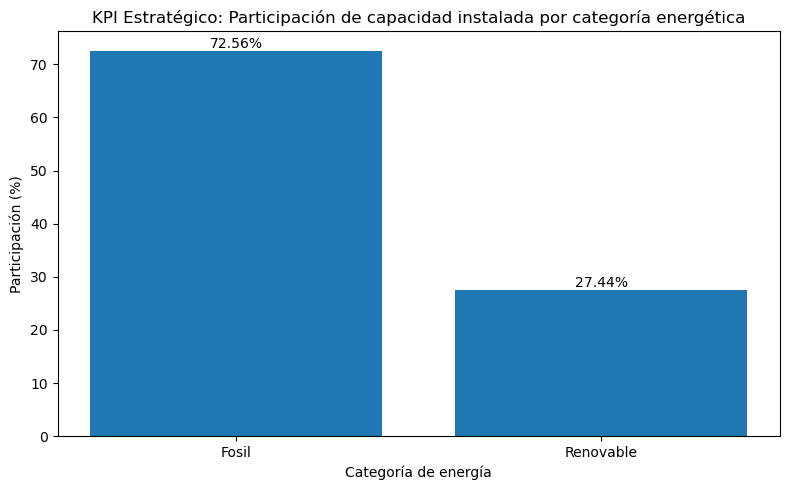

In [12]:
import matplotlib.pyplot as plt

# Convertir KPI estratégico a Pandas para graficar
df_est = kpi_estrategico.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(df_est["categoria_energia"], df_est["Participacion_Porcentaje"])

plt.title("KPI Estratégico: Participación de capacidad instalada por categoría energética")
plt.xlabel("Categoría de energía")
plt.ylabel("Participación (%)")

for i, valor in enumerate(df_est["Participacion_Porcentaje"]):
    plt.text(i, valor, f"{valor}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Este gráfico sirve para explicar si la base está más concentrada en energía renovable o no renovable.

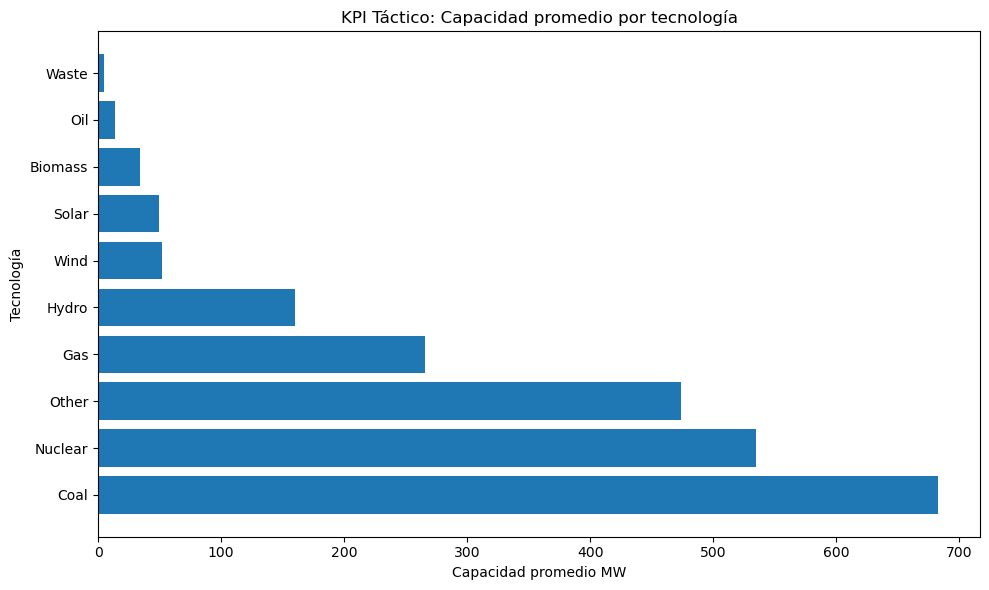

In [13]:
# Convertir KPI táctico a Pandas para graficar
df_tac = kpi_tactico.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(df_tac["tecnologia"], df_tac["Capacidad_Promedio_MW"])

plt.title("KPI Táctico: Capacidad promedio por tecnología")
plt.xlabel("Capacidad promedio MW")
plt.ylabel("Tecnología")

plt.tight_layout()
plt.show()

Este gráfico sirve para decir qué tecnología tiene mayor capacidad promedio.

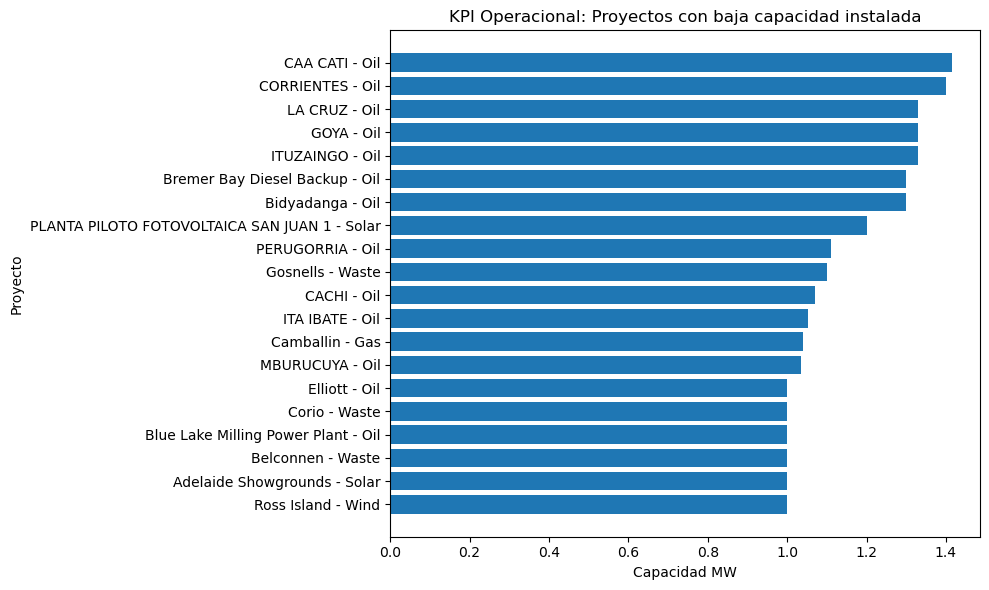

In [15]:
# Convertir proyectos pequeños a Pandas
df_op = kpi_operacional.limit(20).toPandas()

plt.figure(figsize=(10, 6))
plt.barh(df_op["item"], df_op["capacidad_mw"])

plt.title("KPI Operacional: Proyectos con baja capacidad instalada")
plt.xlabel("Capacidad MW")
plt.ylabel("Proyecto")

plt.tight_layout()
plt.show()

Este gráfico muestra los proyectos más pequeños que podrían necesitar seguimiento.


## Storytelling de los resultados

A partir del análisis realizado, los datos permiten construir una historia orientada a la toma de decisiones en el sector energético.

Desde una mirada **estratégica**, la distribución de la capacidad instalada por categoría energética permite observar el peso que tienen las energías renovables dentro del conjunto de proyectos analizados. Este indicador es relevante para la alta dirección, ya que permite evaluar el avance hacia una matriz energética más sustentable.

Desde una mirada **táctica**, la comparación de capacidad promedio por tecnología permite identificar qué fuentes energéticas presentan mayor escala de generación. Esta información puede ser utilizada por gerentes o encargados de planificación para priorizar inversiones, comparar tecnologías y definir estrategias de desarrollo energético.

Desde una mirada **operacional**, la identificación de proyectos con baja capacidad instalada permite detectar casos que podrían requerir seguimiento específico. Estos proyectos pueden ser relevantes para supervisores o analistas, ya que podrían necesitar revisión técnica, monitoreo de desempeño o evaluación de eficiencia.

En conclusión, el análisis permite pasar de una base de datos técnica a un relato útil para la gestión, donde cada KPI responde a una necesidad distinta dentro de la organización.